In [1]:
import numpy as np  
import cv2  
import matplotlib.pyplot as plt

In [2]:

cap = cv2.VideoCapture(r"C:\Users\Menaka\Downloads\batter1.mp4")  
feature_params = dict( maxCorners = 100, qualityLevel = 0.3, minDistance = 7, blockSize = 7 )  
lk_params = dict( winSize = (15, 15), maxLevel = 2, criteria = (cv2.TERM_CRITERIA_EPS | 
cv2.TERM_CRITERIA_COUNT, 10, 0.03))  
color = np.random.randint(0, 255, (100, 3))  
ret, old_frame = cap.read()  
if not ret: 
    print("Error: Could not read first frame.") 
    cap.release() 
    cv2.destroyAllWindows() 
    exit() 
old_frame = cv2.resize(old_frame, (500, 500)) 
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)  
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)   
mask = np.zeros_like(old_frame)  
while True:  
    ret, frame = cap.read()  
    if not ret: 
        break   
    frame = cv2.resize(frame, (500, 500)) 
    cv2.imshow('Original Frame', frame) 
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)  
    if p1 is None or st is None: 
        break 
    good_new = p1[st == 1]  
    good_old = p0[st == 1]  
    for i, (new, old) in enumerate(zip(good_new, good_old)):  
        a, b = new.ravel()  
        c, d = old.ravel()  
        mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2) 
        frame1 = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1) 
    img = cv2.add(frame1, mask)   
    cv2.imshow('Tracked Motion', img)   
    k = cv2.waitKey(25)  
    if k == 27:  
        break 
    old_gray = frame_gray.copy()  
    p0 = good_new.reshape(-1, 1, 2)  
cv2.destroyAllWindows()  
cap.release()

Text(0.5, 1.0, 'Moved Frame')

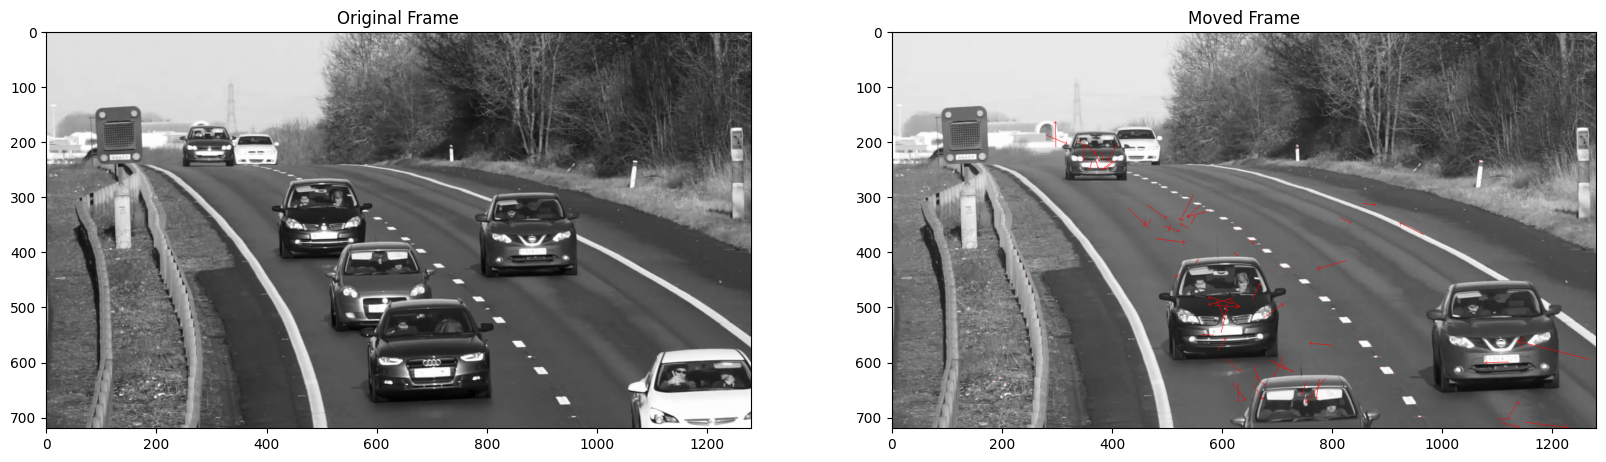

In [3]:
 
img1 = cv2.imread(r"C:\Users\Menaka\Downloads\c1.jpg", cv2.IMREAD_GRAYSCALE) 
img2 = cv2.imread(r"C:\Users\Menaka\Downloads\c2.jpg", cv2.IMREAD_GRAYSCALE) 

img2_bgr = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR) 
p0 = cv2.goodFeaturesToTrack(img1, maxCorners=100, qualityLevel=0.3, minDistance=7) 
lk_params = dict(winSize=(15, 15), maxLevel=2,criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)) 
p1, st, _ = cv2.calcOpticalFlowPyrLK(img1, img2, p0, None, **lk_params) 

for new, old in zip(p1[st == 1], p0[st == 1]): 
    a, b = map(int, new.ravel()) 
    c, d = map(int, old.ravel()) 
    img2_bgr = cv2.arrowedLine(img2_bgr, (c, d), (a, b), (255, 0, 0), 1) 

plt.figure(figsize = (20,20))
plt.subplot(1,2,1)
plt.imshow(img1, cmap = 'gray') 
plt.title('Original Frame')

plt.subplot(1,2,2)
plt.imshow(img2_bgr) 
plt.title('Moved Frame')

